# 3 · Research  🔬

Pick a **saved run** (defaults to the latest) and analyze **when & where** wins vs losses happen.
Pure analysis — it loads a run's saved trades/metrics, no recompute.

*Connected from ←* reads a `runs/run_NNNN/` that **2_backtest** wrote. Findings → back to **1_idea_lab**.

In [1]:
import nbtools as nb
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
import ipywidgets as widgets
from IPython.display import display
import config
from algokit import runs

## Select run  (latest is the default)

In [2]:
run_names = sorted([d for d in __import__("os").listdir(runs.RUNS_DIR) if d.startswith("run_")])
run_dd = widgets.Dropdown(options=run_names, value=run_names[-1], description="Run:")
display(run_dd)

Dropdown(description='Run:', index=2, options=('run_0001', 'run_0002', 'run_0003'), value='run_0003')

## Load it

In [3]:
R = runs.load_run(run_dd.value)
m = R["meta"]
print(f"{m['name']}  |  strategy: {m['strategy']}  |  {m['timestamp']}")
pd.Series(R["config"]).to_frame("config")

run_0003  |  strategy: fanning_mtf  |  2026-06-24T16:57:55


,config
symbol,NQ
htf_tf,1d
ltf_tf,15m
htf_fan,"[5, 500, 0.15]"
ltf_fan,"[5, 100, 0.03]"
n_ma,32
slope_L,5
X,70
htf_gate,50
coil_k,20


## Saved stats  (with plain-English meaning)

In [4]:
nb.metrics_table(R["metrics"])

,metric,value,what it means
0,total_return,23.60%,Total compounded gain over the whole backtest.
1,cagr,1.07%,Compound Annual Growth Rate — return smoothed ...
2,annual_vol,3.53%,How much returns swing (annualized) = risk.
3,sharpe,0.32,"Return per unit of TOTAL risk. >1 good, <0.5 w..."
4,sortino,0.11,Like Sharpe but only DOWNSIDE swings count as ...
5,calmar,0.10,Annual return / worst drawdown — reward vs pain.
6,max_drawdown,-10.40%,Worst peak-to-trough drop the account would ha...
7,exposure,8.85%,Share of time actually holding a position (res...
8,round_trips,817,Number of completed buy->sell trades.
9,win_rate,45.53%,Share of trades that made money.


## Equity curve

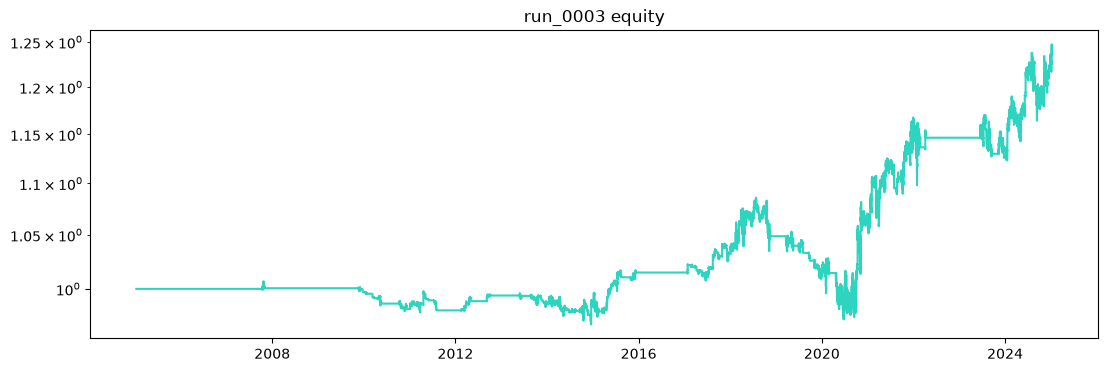

In [5]:
e = R["equity"]
plt.figure(figsize=(13,4)); plt.plot(pd.to_datetime(e["time"]), e["equity"], color="#2dd4bf")
plt.yscale("log"); plt.title(f"{R['meta']['name']} equity"); plt.show()

## Trade log + winners vs losers headline

In [6]:
tr = R["trades"].copy(); tr["result"] = np.where(tr["ret"] > 0, "win", "loss")
display(tr.head(8))
tr.groupby("result").agg(trades=("ret","size"), avg_ret_pct=("ret", lambda s: s.mean()*100),
                         avg_hold=("hold_bars","mean")).round(2)

,entry,exit,entry_px,exit_px,ret,reason,hold_bars,hour_et,dow,bull15,consol15,bull1d,result
0,2007-10-12 16:00:00,2007-10-15 10:45:00,5143.25,5153.50,0.001993,exit,69,12,4,73.313783,26.686217,58.010588,win
1,2007-10-22 17:45:00,2007-10-23 15:45:00,5126.25,5149.25,0.004487,exit,82,13,0,73.313783,26.686217,56.589579,win
2,2007-10-23 18:45:00,2007-10-23 22:45:00,5169.50,5153.50,-0.003095,exit,11,14,1,74.486804,25.513196,56.366676,loss
3,2007-10-29 05:15:00,2007-10-29 09:00:00,5181.00,5176.75,-0.000820,exit,15,1,0,75.855327,24.144673,56.366676,loss
4,2007-10-31 19:45:00,2007-11-01 08:45:00,5201.00,5201.25,0.000048,exit,47,15,2,73.313783,26.686217,57.091112,win
5,2009-11-16 00:30:00,2009-11-16 06:45:00,4705.50,4709.25,0.000797,exit,25,19,0,73.998045,26.001955,54.806353,win
6,2009-11-23 15:00:00,2009-11-23 23:45:00,4710.75,4701.00,-0.002070,exit,30,10,0,81.329423,18.670577,54.806353,loss
7,2009-12-01 09:15:00,2009-12-02 00:30:00,4692.00,4700.00,0.001705,exit,56,4,1,74.682307,25.317693,51.518529,win


,trades,avg_ret_pct,avg_hold
result,,,
loss,445,-0.29,25.20
win,372,0.50,82.65


## When & where do wins vs losses happen?

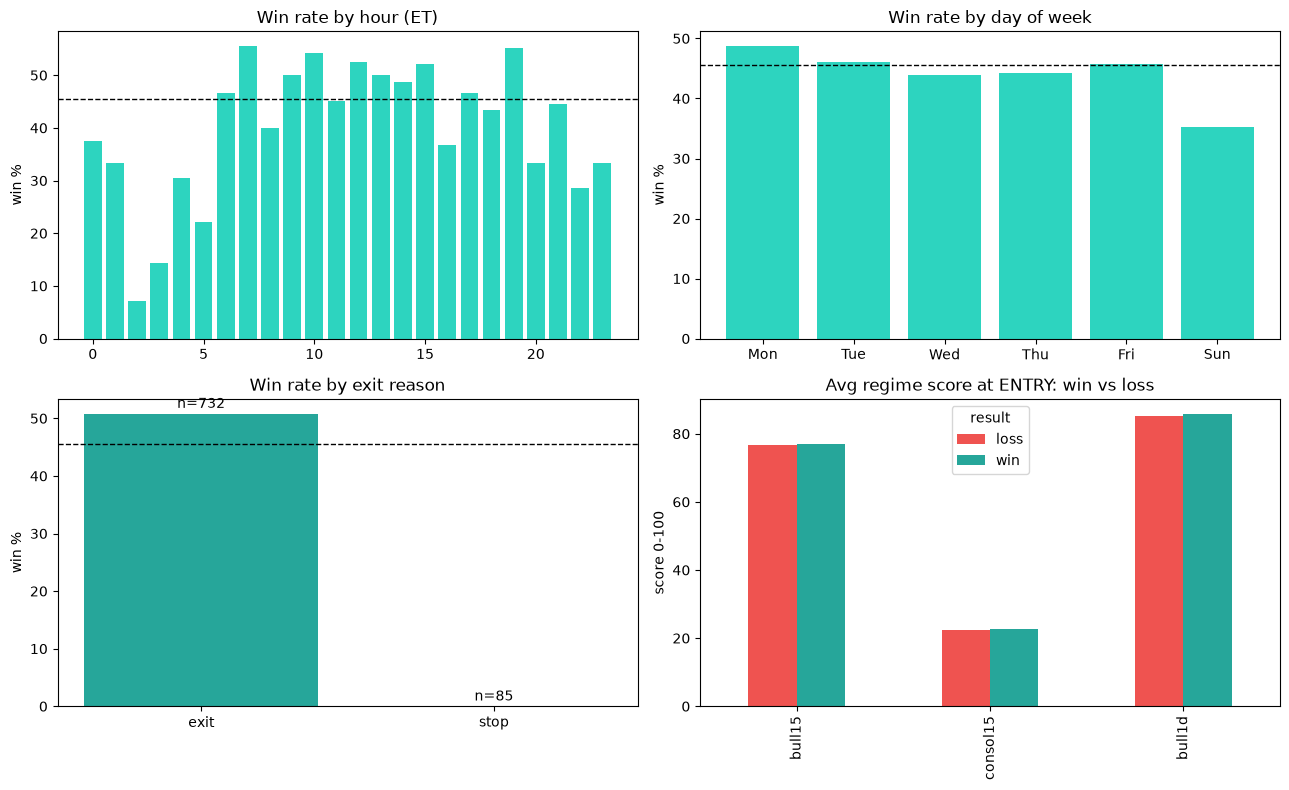

In [7]:
nb.attribution_plot(R["trades"])

---
**The loop:** worst bucket here → new idea in **1_idea_lab** → graduate → **2_backtest** (new run) → back here to compare.
See `runs/RUNS.md` for the full numbered history of what changed each run.